In [8]:
# ============================================================
# CELL 1: Import all libraries we need for EDA
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.io import arff
import warnings

warnings.filterwarnings('ignore')  # hides unnecessary warning messages

# Makes all our plots look clean and professional
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")

print("All imports successful!")

All imports successful!


In [9]:
# ============================================================
# CELL 2: Load the .arff file and convert to pandas DataFrame
# ============================================================

# Load the raw .arff file
raw_data, meta = arff.loadarff('../data/raw/Training Dataset.arff')

# Convert to a pandas DataFrame (the table format we'll work with)
df = pd.DataFrame(raw_data)

# The .arff format stores numbers as bytes (e.g. b'1' instead of 1)
# This line converts every column to proper integers
df = df.applymap(lambda x: int(x))

print(f"Dataset loaded successfully!")
print(f"Shape: {df.shape}")  
# Shape tells us: (number of rows, number of columns)

Dataset loaded successfully!
Shape: (11055, 31)


In [10]:
# ============================================================
# CELL 3: Get a first look at what our data actually looks like
# ============================================================

print("=" * 55)
print("FIRST 5 ROWS OF THE DATASET")
print("=" * 55)
display(df.head())

print("\n")
print("=" * 55)
print("LAST 5 ROWS OF THE DATASET")
print("=" * 55)
display(df.tail())

print("\n")
print("=" * 55)
print("COLUMN NAMES (our 30 features + 1 target)")
print("=" * 55)
for i, col in enumerate(df.columns, 1):
    print(f"{i:2}. {col}")

FIRST 5 ROWS OF THE DATASET


,having_IP_Address,URL_Length,Shortining_Service,having_At_Symbol,double_slash_redirecting,Prefix_Suffix,having_Sub_Domain,SSLfinal_State,Domain_registeration_length,Favicon,...,popUpWidnow,Iframe,age_of_domain,DNSRecord,web_traffic,Page_Rank,Google_Index,Links_pointing_to_page,Statistical_report,Result
0,-1,1,1,1,-1,-1,-1,-1,-1,1,...,1,1,-1,-1,-1,-1,1,1,-1,-1
1,1,1,1,1,1,-1,0,1,-1,1,...,1,1,-1,-1,0,-1,1,1,1,-1
2,1,0,1,1,1,-1,-1,-1,-1,1,...,1,1,1,-1,1,-1,1,0,-1,-1
3,1,0,1,1,1,-1,-1,-1,1,1,...,1,1,-1,-1,1,-1,1,-1,1,-1
4,1,0,-1,1,1,-1,1,1,-1,1,...,-1,1,-1,-1,0,-1,1,1,1,1




LAST 5 ROWS OF THE DATASET


,having_IP_Address,URL_Length,Shortining_Service,having_At_Symbol,double_slash_redirecting,Prefix_Suffix,having_Sub_Domain,SSLfinal_State,Domain_registeration_length,Favicon,...,popUpWidnow,Iframe,age_of_domain,DNSRecord,web_traffic,Page_Rank,Google_Index,Links_pointing_to_page,Statistical_report,Result
11050,1,-1,1,-1,1,1,1,1,-1,-1,...,-1,-1,1,1,-1,-1,1,1,1,1
11051,-1,1,1,-1,-1,-1,1,-1,-1,-1,...,-1,1,1,1,1,1,1,-1,1,-1
11052,1,-1,1,1,1,-1,1,-1,-1,1,...,1,1,1,1,1,-1,1,0,1,-1
11053,-1,-1,1,1,1,-1,-1,-1,1,-1,...,-1,1,1,1,1,-1,1,1,1,-1
11054,-1,-1,1,1,1,-1,-1,-1,1,1,...,1,1,-1,1,-1,-1,-1,1,-1,-1




COLUMN NAMES (our 30 features + 1 target)
 1. having_IP_Address
 2. URL_Length
 3. Shortining_Service
 4. having_At_Symbol
 5. double_slash_redirecting
 6. Prefix_Suffix
 7. having_Sub_Domain
 8. SSLfinal_State
 9. Domain_registeration_length
10. Favicon
11. port
12. HTTPS_token
13. Request_URL
14. URL_of_Anchor
15. Links_in_tags
16. SFH
17. Submitting_to_email
18. Abnormal_URL
19. Redirect
20. on_mouseover
21. RightClick
22. popUpWidnow
23. Iframe
24. age_of_domain
25. DNSRecord
26. web_traffic
27. Page_Rank
28. Google_Index
29. Links_pointing_to_page
30. Statistical_report
31. Result


In [11]:
# ============================================================
# CELL 4: Understand the basic statistics of our dataset
# ============================================================

print("=" * 55)
print("DATASET OVERVIEW")
print("=" * 55)
print(f"\nTotal websites in dataset : {len(df)}")
print(f"Total columns             : {len(df.columns)}")
print(f"Feature columns           : {len(df.columns) - 1}  (all except 'Result')")
print(f"Target column             : Result")

print("\n")
print("=" * 55)
print("CHECKING FOR MISSING VALUES")
print("=" * 55)
missing = df.isnull().sum().sum()
print(f"Total missing values: {missing}")
if missing == 0:
    print("✅ No missing values! Dataset is clean.")
else:
    print("⚠️ We have missing values — we'll need to handle them.")

print("\n")
print("=" * 55)
print("DATA TYPES OF EACH COLUMN")
print("=" * 55)
print(df.dtypes.value_counts())
print("\nAll columns should show 'int64'")

DATASET OVERVIEW

Total websites in dataset : 11055
Total columns             : 31
Feature columns           : 30  (all except 'Result')
Target column             : Result


CHECKING FOR MISSING VALUES
Total missing values: 0
✅ No missing values! Dataset is clean.


DATA TYPES OF EACH COLUMN
int64    31
Name: count, dtype: int64

All columns should show 'int64'


CLASS DISTRIBUTION

Phishing websites  (Result =  1): 6,157
Legitimate websites (Result = -1): 4,898
Total                            : 11,055

Phishing   %: 55.7%
Legitimate %: 44.3%


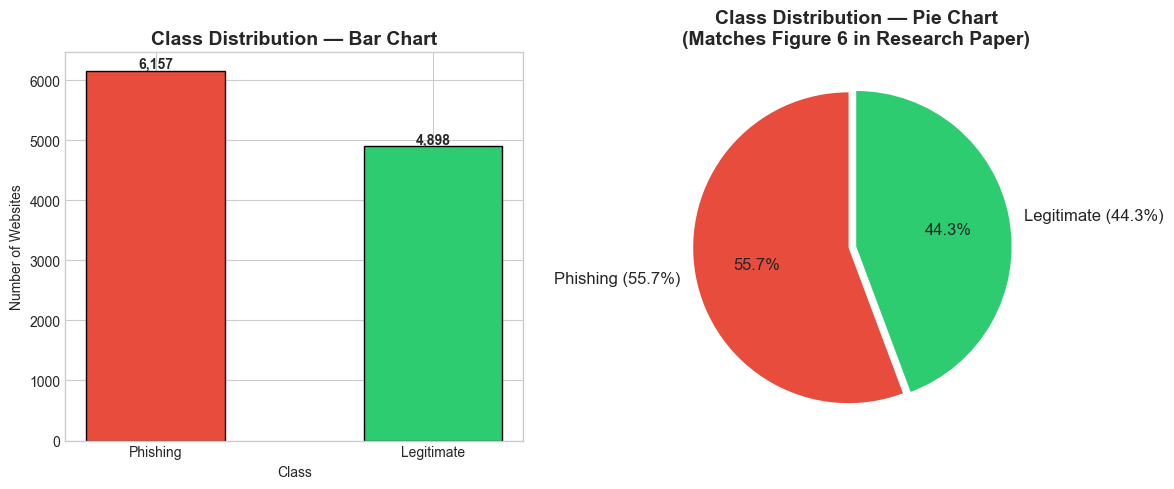


✅ Chart saved to data/processed/


In [12]:
# ============================================================
# CELL 5: Check how many phishing vs legitimate sites we have
# ============================================================

# Count each class
class_counts = df['Result'].value_counts()
class_labels = {1: 'Phishing', -1: 'Legitimate'}

print("=" * 55)
print("CLASS DISTRIBUTION")
print("=" * 55)
print(f"\nPhishing websites  (Result =  1): {class_counts[1]:,}")
print(f"Legitimate websites (Result = -1): {class_counts[-1]:,}")
print(f"Total                            : {len(df):,}")
print(f"\nPhishing   %: {class_counts[1]/len(df)*100:.1f}%")
print(f"Legitimate %: {class_counts[-1]/len(df)*100:.1f}%")

# ---- Visualization ----
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Bar chart
bars = ax1.bar(
    ['Phishing', 'Legitimate'],
    [class_counts[1], class_counts[-1]],
    color=['#e74c3c', '#2ecc71'],
    edgecolor='black',
    width=0.5
)
ax1.set_title('Class Distribution — Bar Chart', fontsize=14, fontweight='bold')
ax1.set_ylabel('Number of Websites')
ax1.set_xlabel('Class')
# Add count labels on top of each bar
for bar, count in zip(bars, [class_counts[1], class_counts[-1]]):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
             f'{count:,}', ha='center', fontweight='bold')

# Pie chart (matches Figure 6 in the paper)
ax2.pie(
    [class_counts[1], class_counts[-1]],
    labels=['Phishing (55.7%)', 'Legitimate (44.3%)'],
    colors=['#e74c3c', '#2ecc71'],
    autopct='%1.1f%%',
    startangle=90,
    explode=(0.05, 0),  # slightly pop out the phishing slice
    textprops={'fontsize': 12}
)
ax2.set_title('Class Distribution — Pie Chart\n(Matches Figure 6 in Research Paper)',
              fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('../data/processed/class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("\n✅ Chart saved to data/processed/")

In [13]:
# ============================================================
# CELL 6: Print a human-readable explanation of all 30 features
# ============================================================

feature_explanations = {
    'having_IP_Address'      : 'Does URL use raw IP instead of domain? (e.g. http://192.168.1.1/) — Phishers avoid domain registration',
    'URL_Length'             : 'Is the URL very long? — Phishing URLs are often long to hide the real domain',
    'Shortining_Service'     : 'Was a URL shortener used? (bit.ly, tinyurl) — Used to hide destination',
    'having_At_Symbol'       : 'Does URL have @ symbol? — Browser ignores everything before @, used to deceive',
    'double_slash_redirecting': 'Does URL have // after the protocol? — Used for redirection tricks',
    'Prefix_Suffix'          : 'Does domain have - (hyphen)? (e.g. google-login.com) — Common phishing trick',
    'having_Sub_Domain'      : 'How many subdomains? (e.g. secure.login.evil.com) — More dots = more suspicious',
    'SSLfinal_State'         : 'Does site have valid HTTPS certificate? — Legit sites usually do',
    'Domain_registeration_length': 'How long is domain registered for? — Phishers register short-term',
    'Favicon'                : 'Is the favicon loaded from same domain? — Phishers copy favicons from legit sites',
    'port'                   : 'Does URL use unusual port? — Normal sites use 80/443, phishers use others',
    'HTTPS_token'            : 'Does URL have "https" in the domain name? (e.g. https-google.com) — Fake trust signal',
    'Request_URL'            : 'Do page resources load from same domain? — Phishing pages load from external sources',
    'URL_of_Anchor'          : 'Do links on the page point to same domain? — Phishing pages link to legit sites to seem real',
    'Links_in_tags'          : 'Are meta/script/link tags from same domain? — External = suspicious',
    'SFH'                    : 'Where does the form submit data? — Phishing forms send to different server',
    'Submitting_to_email'    : 'Does form submit data via email? — Old phishing trick using mailto:',
    'Abnormal_URL'           : 'Does URL match WHOIS registration info? — Phishing domains are mismatched',
    'Redirect'               : 'How many redirects happen? — Phishing hides behind multiple redirects',
    'on_mouseover'           : 'Does status bar change on hover? — Used to hide real destination URL',
    'RightClick'             : 'Is right-click disabled? — Phishers prevent users from inspecting source',
    'popUpWidnow'            : 'Does site use pop-ups asking for credentials? — Classic phishing behavior',
    'Iframe'                 : 'Does site use hidden iframes? — Used to display legit site inside phishing page',
    'age_of_domain'          : 'How old is the domain? — New domains are more suspicious',
    'DNSRecord'              : 'Does domain have DNS record? — Phishing domains sometimes lack proper DNS',
    'web_traffic'            : 'How much traffic does site get? (Alexa rank) — Legit sites have more traffic',
    'Page_Rank'              : "What is Google's PageRank? — Legit sites have higher rank",
    'Google_Index'           : 'Is site indexed by Google? — Phishing sites avoid Google indexing',
    'Links_pointing_to_page' : 'How many external links point here? — Legit sites have more backlinks',
    'Statistical_report'     : 'Is domain flagged in statistical phishing reports? — Known bad actors'
}

print("=" * 70)
print(f"{'#':<4} {'FEATURE NAME':<32} EXPLANATION")
print("=" * 70)

for i, (feature, explanation) in enumerate(feature_explanations.items(), 1):
    # Handle the case where feature might not exist in our df
    if feature in df.columns:
        print(f"{i:<4} {feature:<32} {explanation}")
        print()

#    FEATURE NAME                     EXPLANATION
1    having_IP_Address                Does URL use raw IP instead of domain? (e.g. http://192.168.1.1/) — Phishers avoid domain registration

2    URL_Length                       Is the URL very long? — Phishing URLs are often long to hide the real domain

3    Shortining_Service               Was a URL shortener used? (bit.ly, tinyurl) — Used to hide destination

4    having_At_Symbol                 Does URL have @ symbol? — Browser ignores everything before @, used to deceive

5    double_slash_redirecting         Does URL have // after the protocol? — Used for redirection tricks

6    Prefix_Suffix                    Does domain have - (hyphen)? (e.g. google-login.com) — Common phishing trick

7    having_Sub_Domain                How many subdomains? (e.g. secure.login.evil.com) — More dots = more suspicious

8    SSLfinal_State                   Does site have valid HTTPS certificate? — Legit sites usually do

9    Domain_registe

In [14]:
# ============================================================
# CELL 7: See how each feature splits between -1, 0, and 1
# ============================================================

# Separate features (X) from target (y)
X = df.drop('Result', axis=1)   # everything except the last column
y = df['Result']                 # just the Result column

print("FEATURE VALUE COUNTS (how often each value appears per feature)")
print("=" * 60)
print(f"{'Feature':<35} {'Value -1':>10} {'Value 0':>10} {'Value 1':>10}")
print("-" * 60)

for col in X.columns:
    counts = X[col].value_counts().sort_index()
    v_minus1 = counts.get(-1, 0)
    v_zero   = counts.get(0, 0)
    v_one    = counts.get(1, 0)
    print(f"{col:<35} {v_minus1:>10,} {v_zero:>10,} {v_one:>10,}")

FEATURE VALUE COUNTS (how often each value appears per feature)
Feature                               Value -1    Value 0    Value 1
------------------------------------------------------------
having_IP_Address                        3,793          0      7,262
URL_Length                               8,960        135      1,960
Shortining_Service                       1,444          0      9,611
having_At_Symbol                         1,655          0      9,400
double_slash_redirecting                 1,429          0      9,626
Prefix_Suffix                            9,590          0      1,465
having_Sub_Domain                        3,363      3,622      4,070
SSLfinal_State                           3,557      1,167      6,331
Domain_registeration_length              7,389          0      3,666
Favicon                                  2,053          0      9,002
port                                     1,502          0      9,553
HTTPS_token                              1,796 

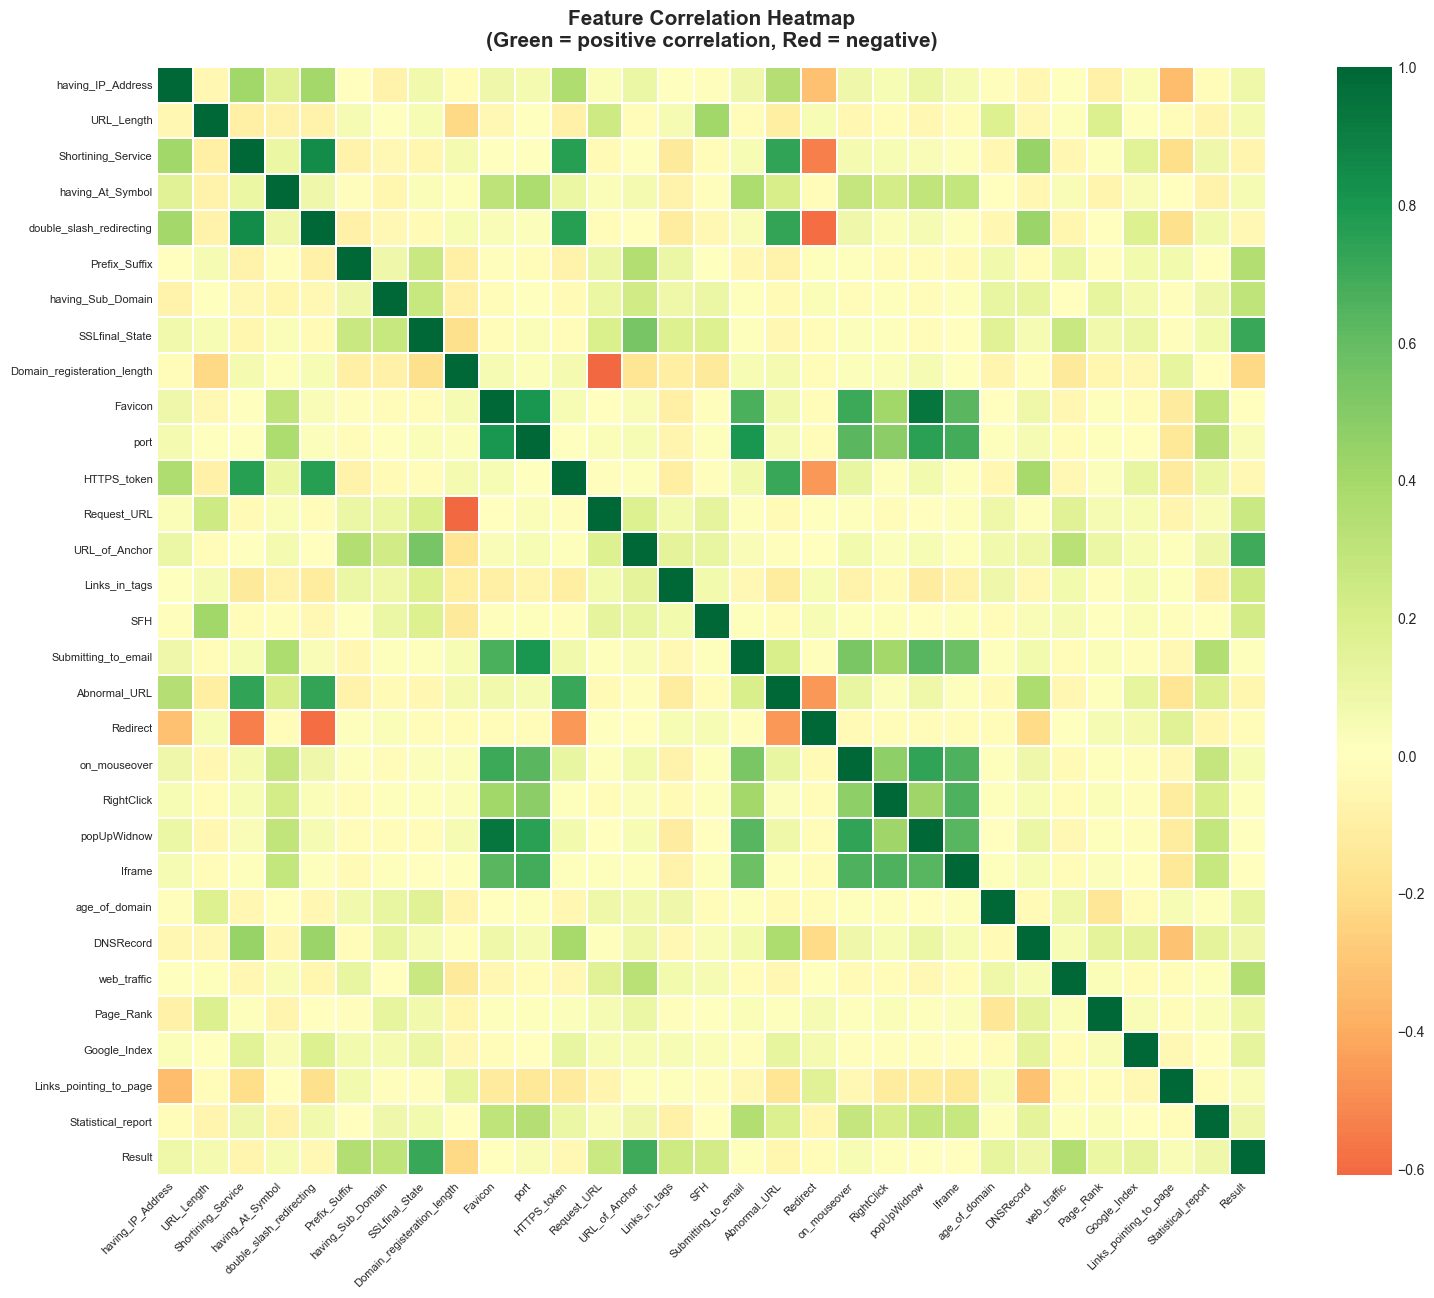

✅ Heatmap saved!

The last row/column (Result) shows how each feature
correlates with whether a site is phishing or legitimate.


In [15]:
# ============================================================
# CELL 8: Heatmap showing which features relate to each other
# ============================================================

plt.figure(figsize=(16, 13))

correlation_matrix = df.corr()

sns.heatmap(
    correlation_matrix,
    annot=False,          # too many cells to show numbers
    cmap='RdYlGn',        # red = negative correlation, green = positive
    center=0,
    linewidths=0.3,
    square=True
)

plt.title('Feature Correlation Heatmap\n(Green = positive correlation, Red = negative)',
          fontsize=15, fontweight='bold', pad=15)
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.yticks(rotation=0, fontsize=8)
plt.tight_layout()
plt.savefig('../data/processed/correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

print("✅ Heatmap saved!")
print("\nThe last row/column (Result) shows how each feature")
print("correlates with whether a site is phishing or legitimate.")

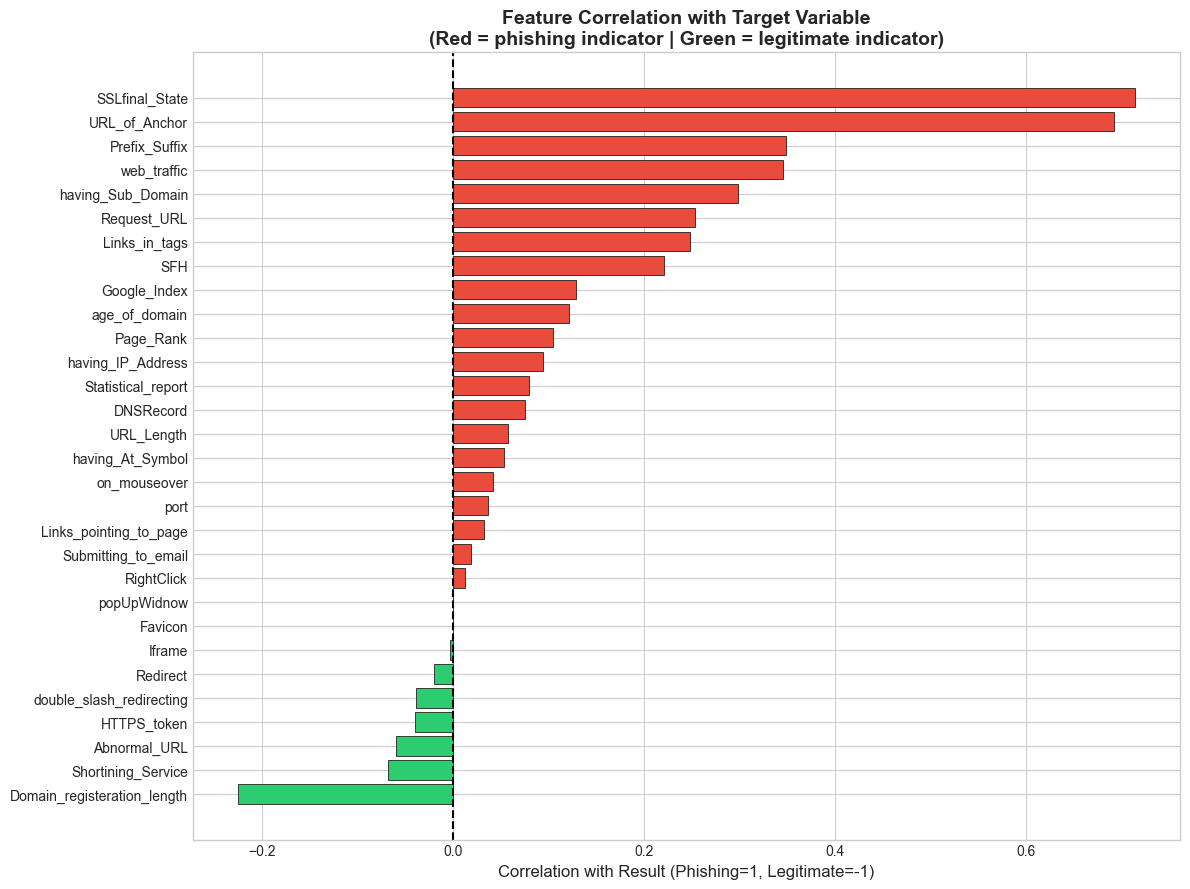


Top 5 PHISHING indicators (most red features):
having_Sub_Domain    0.298323
web_traffic          0.346103
Prefix_Suffix        0.348606
URL_of_Anchor        0.692935
SSLfinal_State       0.714741

Top 5 LEGITIMATE indicators (most green features):
Domain_registeration_length   -0.225789
Shortining_Service            -0.067966
Abnormal_URL                  -0.060488
HTTPS_token                   -0.039854
double_slash_redirecting      -0.038608


In [16]:
# ============================================================
# CELL 9: Find which features matter most for detecting phishing
# ============================================================

# Correlation of each feature WITH the target column
feature_correlation = df.corr()['Result'].drop('Result').sort_values()

plt.figure(figsize=(12, 9))

colors = ['#e74c3c' if x > 0 else '#2ecc71' for x in feature_correlation.values]

bars = plt.barh(
    feature_correlation.index,
    feature_correlation.values,
    color=colors,
    edgecolor='black',
    linewidth=0.5
)

plt.axvline(x=0, color='black', linewidth=1.5, linestyle='--')
plt.xlabel('Correlation with Result (Phishing=1, Legitimate=-1)', fontsize=12)
plt.title('Feature Correlation with Target Variable\n(Red = phishing indicator | Green = legitimate indicator)',
          fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../data/processed/feature_correlation.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nTop 5 PHISHING indicators (most red features):")
print(feature_correlation.tail(5).to_string())
print("\nTop 5 LEGITIMATE indicators (most green features):")
print(feature_correlation.head(5).to_string())

In [17]:
# ============================================================
# CELL 10: Save clean dataset so we don't redo this next time
# ============================================================

# Save the clean DataFrame as CSV
df.to_csv('../data/processed/phishing_dataset_clean.csv', index=False)

# Also save X and y separately for easy loading in Phase 3
X.to_csv('../data/processed/X_features.csv', index=False)
y.to_csv('../data/processed/y_target.csv', index=False)

print("✅ Files saved in data/processed/:")
print("   - phishing_dataset_clean.csv  (full dataset)")
print("   - X_features.csv             (30 features only)")
print("   - y_target.csv               (target labels only)")
print(f"\nDataset summary:")
print(f"  Rows    : {len(df):,}")
print(f"  Features: {len(X.columns)}")
print(f"  Phishing: {(y==1).sum():,} ({(y==1).mean()*100:.1f}%)")
print(f"  Legit   : {(y==-1).sum():,} ({(y==-1).mean()*100:.1f}%)")
print("\n🎉 Phase 2 EDA Complete!")

✅ Files saved in data/processed/:
   - phishing_dataset_clean.csv  (full dataset)
   - X_features.csv             (30 features only)
   - y_target.csv               (target labels only)

Dataset summary:
  Rows    : 11,055
  Features: 30
  Phishing: 6,157 (55.7%)
  Legit   : 4,898 (44.3%)

🎉 Phase 2 EDA Complete!
